# Every denied dollar has a birth certificate
------

In [2]:
# Cell 1: Imports and connection setup
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.db import get_connection

con = get_connection(read_only=True)
print("Connected (read-only) — ready for investigation")

Connected (read-only) — ready for investigation


In [6]:
# A temprary view Dataframe in order to make the dates of this data to accurately show urgency
con.execute("""
    CREATE OR REPLACE TEMP VIEW denial_forensics_v2 AS
    WITH ref AS (
        SELECT MAX(ch.date_of_service) + INTERVAL 30 DAY AS reference_date
        FROM claim_header ch
    )
    SELECT
        df.denial_id,
        df.claim_line_id,
        df.carc_code,
        df.denial_category,
        df.upstream_failure_node,
        df.preventability_flag,
        df.recovery_probability,
        GREATEST(0, 180 - date_diff('day', ch.date_of_service, ref.reference_date))::INTEGER
            AS days_remaining_window,
        GREATEST(0, date_diff('day', ch.date_of_service, ref.reference_date) - 180)::INTEGER
            AS days_past_window,
        df.dollars_at_risk,
        df.recommended_action,
        df.dollars_at_risk * df.recovery_probability *
            (1 + (1 - GREATEST(0, 180 - date_diff('day', ch.date_of_service, ref.reference_date))::DOUBLE / 180))
            AS priority_score
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    CROSS JOIN ref
""")
print("View created: denial_forensics_v2")

View created: denial_forensics_v2


#### Opening -- How much money leaked and where? 

In [6]:
# Opening: Total denied dollars and denial rate
result = con.execute("""
    SELECT
        COUNT(*)                                                              AS total_lines,
        SUM(CASE WHEN carc_code NOT IN ('CO-45', 'PR-1')
                  AND paid_amount = 0 THEN 1 ELSE 0 END)                     AS denied_lines,
        ROUND(100.0 * SUM(CASE WHEN carc_code NOT IN ('CO-45', 'PR-1')
                               AND paid_amount = 0 THEN 1 ELSE 0 END)
              / COUNT(*), 1)                                                  AS denial_rate_pct,
        ROUND(SUM(paid_amount + patient_responsibility + adjustment_amount), 2) AS total_billed,
        ROUND(SUM(CASE WHEN carc_code NOT IN ('CO-45', 'PR-1')
                        AND paid_amount = 0
                       THEN adjustment_amount ELSE 0 END), 2)                AS total_denied_dollars
    FROM remittance_835
""").df()

print(result.to_string(index=False))

 total_lines  denied_lines  denial_rate_pct  total_billed  total_denied_dollars
       69574       10089.0             14.5   88757319.06           12447775.58


#### The initial diagnosis exists here. We look at this gap—billed dollars, denied dollars, total claim lines, and total denied claims—and we zoom in further to find the nuances of what we should do about it.

#### Our goal here in this notebook to see what exactly is leading to this gap AND provide the next, immediate tasks in order to cover this gap. 
-------

In [7]:
# Opening: Net Collection Rate
result = con.execute("""
	SELECT
    ROUND(SUM(paid_amount) * 100.0 / SUM(allowed_amount), 2) AS net_collection_rate
FROM remittance_835
WHERE allowed_amount > 0
""").df()

print(result.to_string(index=False))

 net_collection_rate
               97.49


In [2]:
# Opening: Payer Breakdown
result = con.execute("""
    SELECT
    ch.payer_id,
    COUNT(r.remittance_id)                                                      AS total_lines,
    SUM(CASE WHEN r.paid_amount = 0
              AND r.carc_code NOT IN ('CO-45', 'PR-1') THEN 1 ELSE 0 END)      AS denied_lines,
    ROUND(100.0 * SUM(CASE WHEN r.paid_amount = 0
                           AND r.carc_code NOT IN ('CO-45', 'PR-1') THEN 1 ELSE 0 END)
          / COUNT(*), 1)                                                         AS denial_rate_pct,
    SUM(CASE WHEN r.paid_amount = 0
              AND r.carc_code NOT IN ('CO-45', 'PR-1')
             THEN r.adjustment_amount ELSE 0 END)                                AS denied_dollars
FROM remittance_835 r
JOIN claim_header ch ON r.claim_id = ch.claim_id
GROUP BY ch.payer_id
ORDER BY denial_rate_pct DESC
""").df()

print(result.to_string(index=False))

              payer_id  total_lines  denied_lines  denial_rate_pct  denied_dollars
dual_eligible_cobpayer         3418        1022.0             29.9      1276271.85
 medi_cal_managed_care        31607        5059.0             16.0      6400419.53
    medicare_advantage        13891        1823.0             13.1      2172378.93
        commercial_ppo        20658        2185.0             10.6      2598705.27


-------
#### Chapter 1 -- The Upstream Investigation

In [9]:
# Chapter 1: Which nodes in the care-dollar chain failed
result = con.execute("""
	SELECT
    upstream_failure_node,
    COUNT(*)                          AS denial_count,
    SUM(dollars_at_risk)              AS total_at_risk,
    ROUND(SUM(dollars_at_risk) * 100.0 
          / SUM(SUM(dollars_at_risk)) OVER (), 1) AS pct_of_total,
    ROUND(AVG(recovery_probability), 3) AS avg_recovery_prob
FROM denial_forensics
GROUP BY upstream_failure_node
ORDER BY total_at_risk DESC
""").df()

print(result.to_string(index=False))

upstream_failure_node  denial_count  total_at_risk  pct_of_total  avg_recovery_prob
  prior_authorization          2040     4890631.54          39.3              0.476
               coding          3910     4818146.82          38.7              0.692
              billing          1591     1680743.15          13.5              0.720
   remittance_posting           595      765555.38           6.2              0.550
        credentialing          1505      212264.86           1.7              0.150
       charge_capture           448       80433.83           0.6              0.100


#### In the process of a complete claim and it being paid in full, there are several points where something can go wrong which leads to that claim being denied. This output shows a comprehensive picture of the claims denials in our data based on the different “failure nodes”.

#### The different "failure nodes" present in this project are designed inspired by industry logic and RCM benchmarks in healthcare.
-----

In [10]:
# Chapter 1: Preventable & Nonpreventable Split
result = con.execute("""
	SELECT
    preventability_flag,
    COUNT(*)             AS denial_count,
    SUM(dollars_at_risk) AS dollars_at_risk,
    ROUND(SUM(dollars_at_risk) * 100.0 
          / SUM(SUM(dollars_at_risk)) OVER (), 1) AS pct_of_total
FROM denial_forensics
GROUP BY preventability_flag
""").df()

print(result.to_string(index=False))

 preventability_flag  denial_count  dollars_at_risk  pct_of_total
               False           759       1903690.02          15.3
                True          9330      10544085.56          84.7


In [11]:
# Chapter 1: Preventable denials mapped to failure node
result = con.execute("""
	SELECT
    upstream_failure_node,
    COUNT(*)             AS denial_count,
    SUM(dollars_at_risk) AS addressable_dollars
FROM denial_forensics
WHERE preventability_flag = TRUE
GROUP BY upstream_failure_node
ORDER BY addressable_dollars DESC
""").df()

print(result.to_string(index=False))

upstream_failure_node  denial_count  addressable_dollars
               coding          3910           4818146.82
  prior_authorization          1281           2986941.52
              billing          1591           1680743.15
   remittance_posting           595            765555.38
        credentialing          1505            212264.86
       charge_capture           448             80433.83


---------
#### Chapter 2 -- The Actor Analysis; Is this a provider problem or a payer problem?

In [13]:
# Chapter 2: Top CARC Code per Persona type
result = con.execute("""
    SELECT
        p.persona_type,
        r.carc_code,
        COUNT(*)                      1    AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
    FROM remittance_835 r
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    JOIN denial_forensics df ON r.claim_line_id = df.claim_line_id
    WHERE r.paid_amount = 0
      AND r.carc_code NOT IN ('CO-45', 'PR-1')
    GROUP BY p.persona_type, r.carc_code
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY p.persona_type
        ORDER BY COUNT(*) DESC
    ) = 1
    ORDER BY dollars_at_risk DESC
""").df()

print(result.to_string(index=False))

             persona_type carc_code  denial_count  dollars_at_risk
medical_necessity_denials     CO-57           600       2552387.36
            coding_errors      CO-4          1228       1553466.78
          prior_auth_miss     CO-57           681        434554.16
     credentialing_errors     CO-B7          1505        212264.86
      slow_charge_capture      CO-4           451         79285.17


#### Through this query, we're able to see the the most common CARC codes for each payer.
###### CO-57 = the payer deems the information submitted does not support this level of service
###### CO-4 = the procedure code is inconsistent with the modifier used, or a required modifier is missing
###### CO-B7 = the provider was not certified or eligible to be paid for the specific procedure or service on the date of service
----

Provider × Failure Node — Denial Dollars

          practice_name              persona_type upstream_failure_node  denial_count  dollars_at_risk
Behavioral Health Group      credentialing_errors         credentialing          1505        212264.86
Behavioral Health Group      credentialing_errors                coding           976        139194.97
Behavioral Health Group      credentialing_errors               billing           304         40595.44
Behavioral Health Group      credentialing_errors    remittance_posting           112         15185.32
        Emergency Group             coding_errors                coding          1373       1746327.21
        Emergency Group             coding_errors               billing           745        916103.49
        Emergency Group             coding_errors    remittance_posting           110        142548.21
        Emergency Group             coding_errors   prior_authorization             2          2040.39
Internal Medicine Group       s

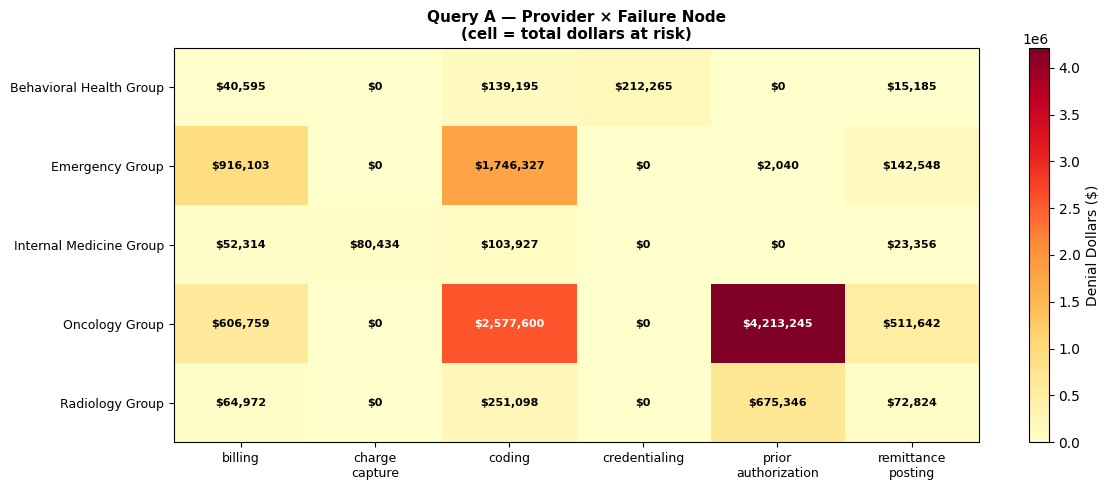

In [2]:
# Provider × Failure Node 
# Which providers are the biggest dollar source for each failure type?
 
provider_node = con.execute("""
    SELECT
        p.practice_name,
        p.persona_type,
        df.upstream_failure_node,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    GROUP BY p.practice_name, p.persona_type, df.upstream_failure_node
    ORDER BY p.practice_name, dollars_at_risk DESC
""").df()
 
print("Provider × Failure Node — Denial Dollars\n")
print(provider_node.to_string(index=False))
 
# Heatmap
pivot_a = provider_node.pivot_table(
    index="practice_name",
    columns="upstream_failure_node",
    values="dollars_at_risk",
    aggfunc="sum"
).fillna(0)
 
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot_a.values, cmap="YlOrRd", aspect="auto")
 
ax.set_xticks(range(len(pivot_a.columns)))
ax.set_xticklabels([c.replace("_", "\n") for c in pivot_a.columns], fontsize=9)
ax.set_yticks(range(len(pivot_a.index)))
ax.set_yticklabels(pivot_a.index, fontsize=9)
 
vmax = pivot_a.values.max()
for i in range(len(pivot_a.index)):
    for j in range(len(pivot_a.columns)):
        val = pivot_a.values[i, j]
        color = "white" if val > vmax * 0.6 else "black"
        ax.text(j, i, f"${val:,.0f}", ha="center", va="center",
                fontsize=8, fontweight="bold", color=color)
 
plt.colorbar(im, ax=ax, label="Denial Dollars ($)")
ax.set_title("Query A — Provider × Failure Node\n(cell = total dollars at risk)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

#### We can see how 'Oncology Group' is the biggest culprit of denials leading to dollars at risk. The claim denial that leads to the most dollars at risk is related to 'prior authorization'.
#### Looking at all the Providers, the ranking of the providers with the most dollars at risk is thus:
###### 1. Oncology Group
###### 2. Emergency Group 
###### 3. Radiology Group
###### 4. Behavioral Group
###### 5. Internal Medicine Group
------

Payer × Failure Node — Denial Dollars

              payer_id upstream_failure_node  denial_count  dollars_at_risk
        commercial_ppo                coding          1021       1376026.81
        commercial_ppo   prior_authorization           269        706129.87
        commercial_ppo               billing           440        449939.80
        commercial_ppo         credentialing           455         66608.79
dual_eligible_cobpayer    remittance_posting           595        765555.38
dual_eligible_cobpayer                coding           172        242256.76
dual_eligible_cobpayer   prior_authorization            56        138707.22
dual_eligible_cobpayer               billing            88        112514.38
dual_eligible_cobpayer         credentialing            74         10920.73
dual_eligible_cobpayer        charge_capture            37          6317.38
 medi_cal_managed_care   prior_authorization          1342       3184547.26
 medi_cal_managed_care                coding     

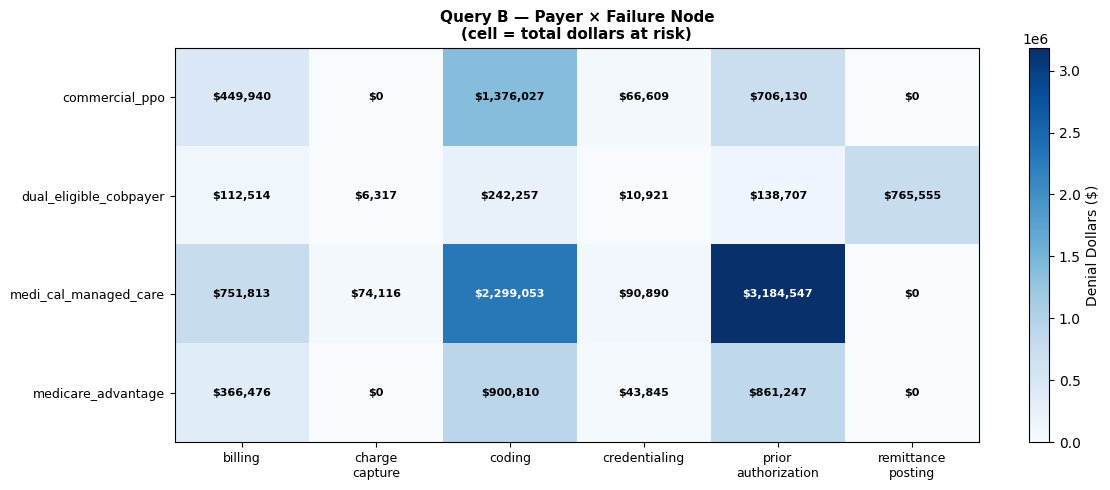

In [3]:
# Payer × Failure Node 
# Which payers are creating the most denial dollars at each failure node?
 
payer_node = con.execute("""
    SELECT
        ch.payer_id,
        df.upstream_failure_node,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    GROUP BY ch.payer_id, df.upstream_failure_node
    ORDER BY ch.payer_id, dollars_at_risk DESC
""").df()
 
print("Payer × Failure Node — Denial Dollars\n")
print(payer_node.to_string(index=False))
 
# Heatmap
pivot_b = payer_node.pivot_table(
    index="payer_id",
    columns="upstream_failure_node",
    values="dollars_at_risk",
    aggfunc="sum"
).fillna(0)
 
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot_b.values, cmap="Blues", aspect="auto")
 
ax.set_xticks(range(len(pivot_b.columns)))
ax.set_xticklabels([c.replace("_", "\n") for c in pivot_b.columns], fontsize=9)
ax.set_yticks(range(len(pivot_b.index)))
ax.set_yticklabels(pivot_b.index, fontsize=9)
 
vmax_b = pivot_b.values.max()
for i in range(len(pivot_b.index)):
    for j in range(len(pivot_b.columns)):
        val = pivot_b.values[i, j]
        color = "white" if val > vmax_b * 0.6 else "black"
        ax.text(j, i, f"${val:,.0f}", ha="center", va="center",
                fontsize=8, fontweight="bold", color=color)
 
plt.colorbar(im, ax=ax, label="Denial Dollars ($)")
ax.set_title("Query B — Payer × Failure Node\n(cell = total dollars at risk)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

#### We did the same analysis but with the Payers. Here, we can see how 'medi_cal_managed_care' is the biggest culprit of denials leading to dollars at risk. Again, the claim denial that leads to the most dollars at risk is related to 'prior authorization'.
#### Looking at all the Payers, the most dollars at risk ranking is thus:
###### 1. medi_cal_managed_care
###### 2. medicare_advantage
###### 3. commercial_ppo
###### 4. dual_eligible_cobpayer
------

Query C — Provider + Payer Combined: Top 20 by Denial Dollars

  practice_name              persona_type               payer_id upstream_failure_node carc_code  denial_count  dollars_at_risk  avg_recovery_prob  expected_recoverable
 Oncology Group medical_necessity_denials  medi_cal_managed_care   prior_authorization     CO-57           381       1645542.82               0.55             905048.55
 Oncology Group medical_necessity_denials  medi_cal_managed_care   prior_authorization     CO-50           256       1081779.55               0.35             378622.84
 Oncology Group medical_necessity_denials  medi_cal_managed_care                coding      CO-4           211        854842.13               0.70             598389.49
 Oncology Group medical_necessity_denials         commercial_ppo                coding      CO-4           164        752104.43               0.70             526473.10
Emergency Group             coding_errors  medi_cal_managed_care                coding      

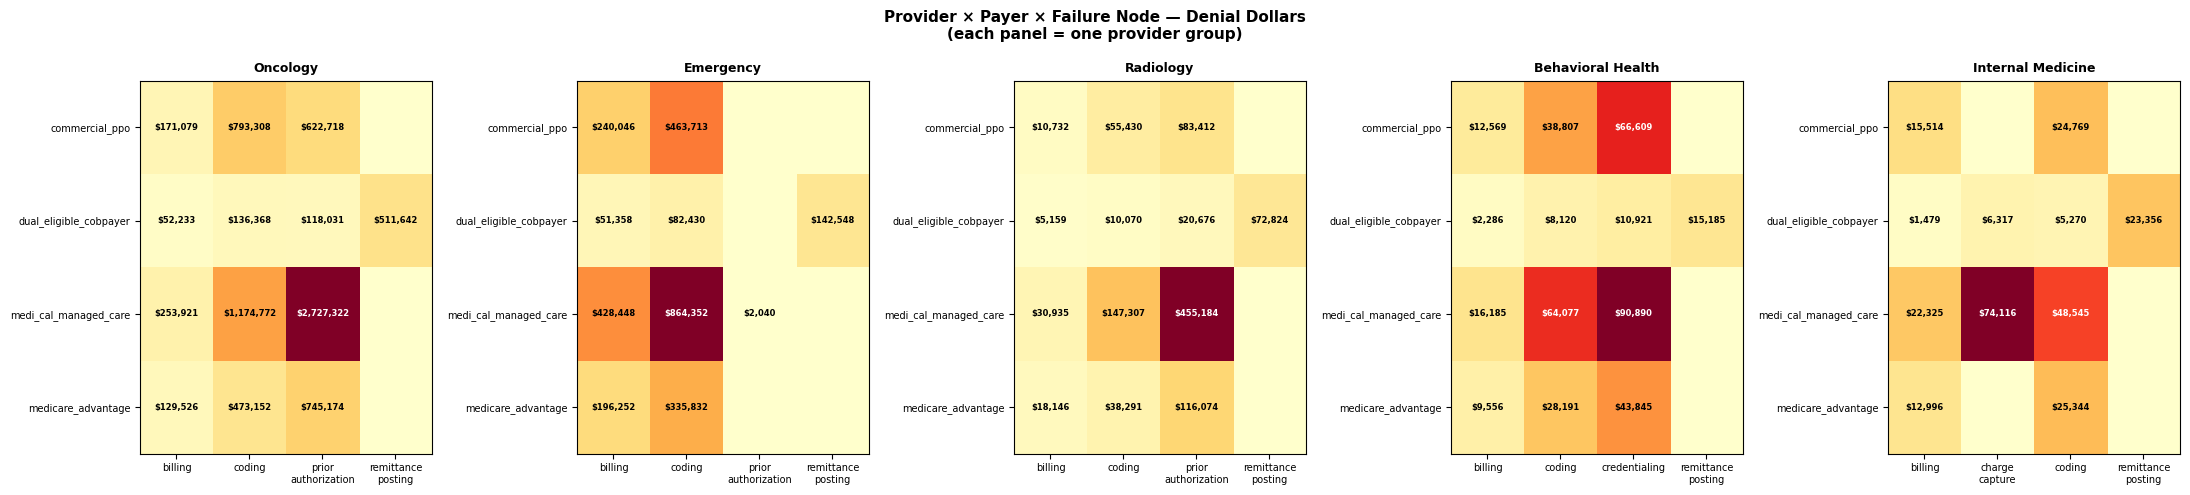

In [4]:
# Provider + Payer Combined
# Where provider failure mode and payer behavior intersect.
# The highest-dollar rows in this table are the specific meetings to call.
 
provider_payer = con.execute("""
    SELECT
        p.practice_name,
        p.persona_type,
        ch.payer_id,
        df.upstream_failure_node,
        df.carc_code,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk,
        ROUND(AVG(df.recovery_probability), 3) AS avg_recovery_prob,
        ROUND(SUM(df.dollars_at_risk * df.recovery_probability), 2) AS expected_recoverable
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    GROUP BY p.practice_name, p.persona_type, ch.payer_id,
             df.upstream_failure_node, df.carc_code
    ORDER BY dollars_at_risk DESC
""").df()
 
print("Query C — Provider + Payer Combined: Top 20 by Denial Dollars\n")
print(provider_payer.head(20).to_string(index=False))
 
# Faceted heatamap -- Provider & Payer X Failure Node
providers = provider_payer["practice_name"].unique()
fig, axes = plt.subplots(1, len(providers), figsize=(22, 5))

for ax, prov in zip(axes, providers):
    subset = provider_payer[provider_payer["practice_name"] == prov]
    pivot = subset.pivot_table(
        index="payer_id",
        columns="upstream_failure_node",
        values="dollars_at_risk",
        aggfunc="sum"
    ).fillna(0)
    
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([c.replace("_", "\n") for c in pivot.columns], fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(prov.replace(" Group", ""), fontsize=9, fontweight="bold")
    
    vmax = pivot.values.max() if pivot.values.max() > 0 else 1
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if val > 0:
                color = "white" if val > vmax * 0.6 else "black"
                ax.text(j, i, f"${val:,.0f}", ha="center", va="center",
                        fontsize=6, fontweight="bold", color=color)

fig.suptitle("Provider × Payer × Failure Node — Denial Dollars\n"
             "(each panel = one provider group)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

#### With this query and the heatmap, we did this analysis with Providers, Payers, and the failure nodes. We're able to see many things in this:
###### - Oncology X medi_cal_managed_care is a huge leader in dollars at risk AND the number of denials. We have to solve that.
###### - There are significantly more dollars at risk with the Oncology group when their denial count are not significantly more than the runner-up: Emergency group healthcare provider. This implies the cost-of-care with the Oncology group has considerably more impact, so their denials mean a lot more compared to the other healthcare providers.
###### - As for the rest of the Payer & Provider combos that are of note here, let's rank the healthcare providers that we notice and the payers that we notice:
###### -- The Healthcare Providers that come up on this radar:
###### 1. Oncology group
###### 2. Emergency group
###### 3. Radiology group

###### -- The Payers:
###### 1. medi_care_managed_care
###### 2. commercial_ppo
###### 3. medicare_advantage
###### 4. dual_eligible_cobpayer
-----

Query D — Payer → CPT Denial Profile

              payer_id cpt_code carc_code  denial_count  dollars_at_risk
        commercial_ppo    99213      CO-4           526        703926.96
        commercial_ppo    99213     CO-57           102        275919.69
        commercial_ppo    99213     CO-16           256        275201.49
        commercial_ppo    99213     CO-50            45        125251.68
        commercial_ppo    45378      CO-4            61        120074.68
        commercial_ppo    95117      CO-4            60         97598.57
        commercial_ppo    96372      CO-4            50         82221.86
        commercial_ppo    45378     CO-97            65         75719.72
        commercial_ppo    95004      CO-4            32         55298.28
        commercial_ppo    81025      CO-4            25         39647.22
        commercial_ppo    94010      CO-4            34         38934.89
        commercial_ppo    99213     CO-B7           248         37555.43
        comme

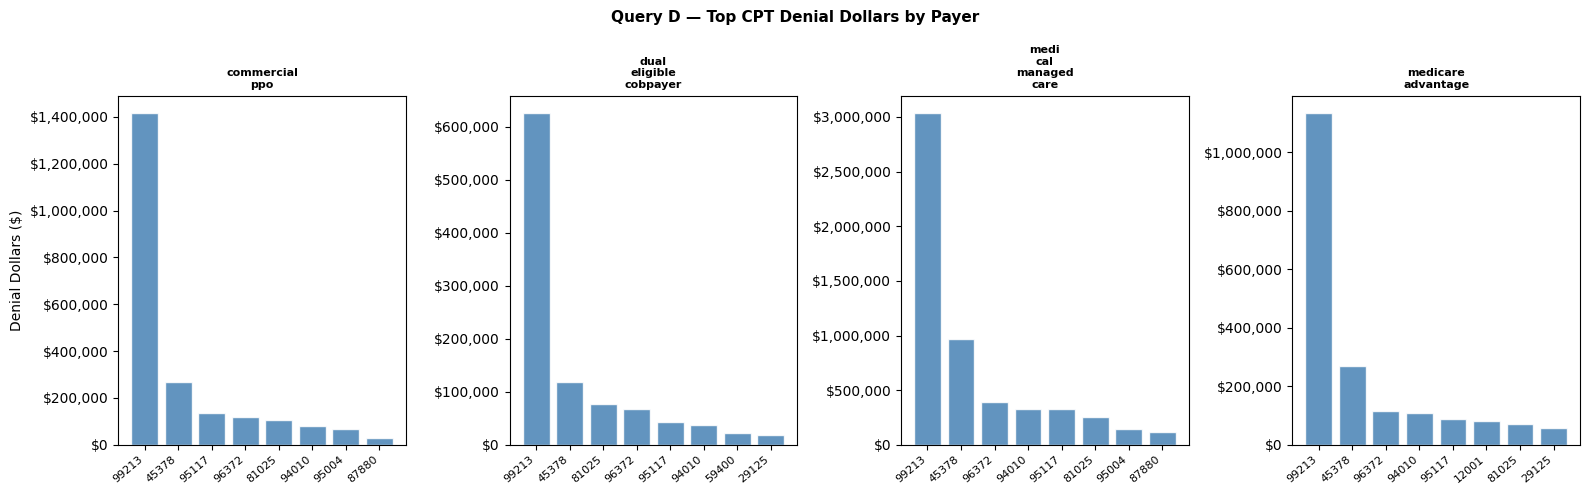

In [7]:
# Payer → CPT Profile 
# For each payer: which CPT codes are generating the most denial dollars?
# Grouped by payer first, then by CPT — shows payer-specific denial behavior.
 
payer_cpt = con.execute("""
    SELECT
        ch.payer_id,
        cl.cpt_code,
        df.carc_code,
        COUNT(*)                          AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2) AS dollars_at_risk
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN claim_line cl    ON r.claim_line_id = cl.claim_line_id
    GROUP BY ch.payer_id, cl.cpt_code, df.carc_code
    HAVING COUNT(*) >= 5
    ORDER BY ch.payer_id, dollars_at_risk DESC
""").df()
 
print("Query D — Payer → CPT Denial Profile\n")
print(payer_cpt.to_string(index=False))
 
# Faceted: one panel per payer, top CPTs by dollars
payers = payer_cpt["payer_id"].unique()
fig, axes = plt.subplots(1, len(payers), figsize=(16, 5), sharey=False)
if len(payers) == 1:
    axes = [axes]
 
for ax, payer in zip(axes, payers):
    subset = (payer_cpt[payer_cpt["payer_id"] == payer]
              .groupby("cpt_code")["dollars_at_risk"]
              .sum()
              .sort_values(ascending=False)
              .head(8))
    if subset.empty:
        ax.set_visible(False)
        continue
    bars = ax.bar(range(len(subset)), subset.values,
                  color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels(subset.index, rotation=40, ha="right", fontsize=8)
    ax.set_title(payer.replace("_", "\n"), fontsize=8, fontweight="bold")
    ax.set_ylabel("Denial Dollars ($)" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
 
fig.suptitle("Query D — Top CPT Denial Dollars by Payer", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

#### Looking at the denials from this lens, we can see that the most common CPT code that lead to dollars at risk is '99213'. This code generally means, "an established patient visit requiring low-complexity medical decision making (MDM) or 20–29 minutes of total provider time."
#### Generally, there are a few causes to denials when this CPT code is used:
###### - The status of the patient is wrong. An *established* patient is one that has been seen in the last 3 years.
###### - The documentation of the visit doesn't support this code's intensity. This code reflects "minimal intensity" when there are several other versions of this code that denote higher intensities.
###### - There's missing pieces of information in the documentation.
###### - This code is missing or has the wrong modifier. There are modifiers to CPT codes that indicate an additional action about the visit and to bill only once. Otherwise a payer's system wonders why they're billing twice and denies this CPT code. For example, the modifier 25 denotes this about a visit, so a payer's system must ignore billing this claim and focus on the other action.
###### - Using this CPT code for a non-outpatient setting (like telehealth) almost always results in a denial. In a situation like a telehealth visit, modifier 95 would be applicable.

--------
#### Chapter 3 -- The Recovery Map

In [4]:
# Chapter 3: How much is still winnable, broken down by urgency
result = con.execute("""
    SELECT
        CASE 
            WHEN days_remaining_window <= 30  THEN '1. Critical  (≤30 days)'
            WHEN days_remaining_window <= 60  THEN '2. Urgent    (31-60 days)'
            WHEN days_remaining_window <= 90  THEN '3. Active    (61-90 days)'
            ELSE                                   '4. Standard  (90+ days)'
        END                                         AS urgency_tier,
        COUNT(*)                                    AS denial_count,
        ROUND(SUM(dollars_at_risk), 2)              AS dollars_at_risk,
        ROUND(AVG(recovery_probability), 3)         AS avg_recovery_prob,
        ROUND(SUM(dollars_at_risk 
              * recovery_probability), 2)           AS expected_recovery
    FROM denial_forensics_v2
    WHERE days_remaining_window > 0
      AND recommended_action != 'write_off'
    GROUP BY urgency_tier
    ORDER BY urgency_tier
""").df()

print(result.to_string(index=True))

                urgency_tier  denial_count  dollars_at_risk  avg_recovery_prob  expected_recovery
0    1. Critical  (≤30 days)           115        133990.28              0.614           81819.65
1  2. Urgent    (31-60 days)           114        120553.90              0.542           73036.39
2  3. Active    (61-90 days)           142        129496.01              0.566           72656.61
3    4. Standard  (90+ days)           223        269120.53              0.549          153755.67


In [7]:
# Chapter 3: Priority worklist — what to work first
result = con.execute("""
    SELECT
    df.denial_id,
    ch.claim_id,
    p.practice_name,
    ch.payer_id,
    ch.date_of_service,
    df.carc_code,
    df.denial_category,
    df.upstream_failure_node,
    df.days_remaining_window,
    df.dollars_at_risk,
    df.recovery_probability,
    df.priority_score,
    df.recommended_action
FROM denial_forensics_v2 df
JOIN remittance_835 r  ON df.claim_line_id = r.claim_line_id
JOIN claim_header ch   ON r.claim_id = ch.claim_id
JOIN provider p        ON ch.provider_id = p.provider_id
WHERE df.days_remaining_window > 0
ORDER BY df.priority_score DESC
LIMIT 50
""").df()

print(f"Active denials within appeal window: {len(result)}")
print("="*70)
print("AR PRIORITY WORK QUEUE — Top 10 (Active Window Only)")
print("="*70)
for i, row in result.head(10).iterrows():
    print(f"""
#{i+1}  PRIORITY SCORE: {row['priority_score']:,.0f}
   Claim:        {row['claim_id'][:8]}...
   Provider:     {row['practice_name']}
   Payer:        {row['payer_id']}
   Service Date: {row['date_of_service']}
   ----------------------------------------------------------------
   CARC:         {row['carc_code']}  ({row['denial_category']})
   Failure Node: {row['upstream_failure_node']}
   $ at Risk:    ${row['dollars_at_risk']:,.2f}
   Recovery Prob:{row['recovery_probability']:.0%}
   Days Left:    {row['days_remaining_window']}
   ACTION:       {row['recommended_action'].upper().replace('_', ' ')}
""")
    print("-"*70)

Active denials within appeal window: 50
AR PRIORITY WORK QUEUE — Top 10 (Active Window Only)

#1  PRIORITY SCORE: 16,658
   Claim:        73c4df7d...
   Provider:     Oncology Group
   Payer:        medi_cal_managed_care
   Service Date: 2016-12-31 00:00:00
   ----------------------------------------------------------------
   CARC:         CO-16  (missing_information)
   Failure Node: billing
   $ at Risk:    $11,763.96
   Recovery Prob:72%
   Days Left:    6
   ACTION:       CORRECT RESUBMIT

----------------------------------------------------------------------

#2  PRIORITY SCORE: 11,259
   Claim:        a1982d50...
   Provider:     Oncology Group
   Payer:        medi_cal_managed_care
   Service Date: 2017-02-16 00:00:00
   ----------------------------------------------------------------
   CARC:         CO-16  (missing_information)
   Failure Node: billing
   $ at Risk:    $9,168.43
   Recovery Prob:72%
   Days Left:    53
   ACTION:       CORRECT RESUBMIT

----------------------

#### This query and list is pulled to show the organization what we should work on RIGHT NOW in order to recover $$$. This query considers priority by the 'recovery probability', the dollars at risk, and the days left (in the time frame of this data) to weigh the urgency and priority.
-----

In [13]:
# Chapter 3: Where should leadership focus process improvement effort?
leadership_focus = con.execute("""
    SELECT
        df.upstream_failure_node,
        df.carc_code,
        df.denial_category,
        COUNT(*)                                                       AS open_denials,
        ROUND(SUM(df.dollars_at_risk), 2)                              AS total_dollars_at_risk,
        ROUND(AVG(df.recovery_probability), 3)                         AS avg_recovery_prob,
        ROUND(AVG(df.days_past_window), 1)                             AS avg_days_past_window,
        ROUND(SUM(df.dollars_at_risk * df.recovery_probability), 2)    AS expected_recoverable
    FROM denial_forensics_v2 df
    WHERE df.days_remaining_window = 0
    GROUP BY df.upstream_failure_node, df.carc_code, df.denial_category
    ORDER BY total_dollars_at_risk DESC
""").df()

print("="*70)
print("LEADERSHIP FOCUS — Aged Denial Backlog by Failure Type")
print("="*70)
print("These denial categories have exited their appeal window.")
print("Framing: not 'work this claim' but 'this failure type keeps")
print("producing denials that age into write-off territory —")
print("fix the upstream process.'")
print("="*70)

for i, row in leadership_focus.iterrows():
    print(f"""
#{i+1}  TOTAL AT RISK: ${row['total_dollars_at_risk']:,.2f}
   Failure Node: {row['upstream_failure_node']}
   CARC:         {row['carc_code']}  ({row['denial_category']})
   ----------------------------------------------------------------
   Open Denials:      {row['open_denials']:,}
   Avg Recovery Prob: {row['avg_recovery_prob']:.0%}
   Avg Days Past Window: {row['avg_days_past_window']:.0f}
   Expected Recoverable: ${row['expected_recoverable']:,.2f}
""")
    print("-"*70)

LEADERSHIP FOCUS — Aged Denial Backlog by Failure Type
These denial categories have exited their appeal window.
Framing: not 'work this claim' but 'this failure type keeps
producing denials that age into write-off territory —
fix the upstream process.'

#1  TOTAL AT RISK: $3,790,281.31
   Failure Node: coding
   CARC:         CO-4  (coding_error)
   ----------------------------------------------------------------
   Open Denials:      3,068
   Avg Recovery Prob: 70%
   Avg Days Past Window: 1230
   Expected Recoverable: $2,653,196.92

----------------------------------------------------------------------

#2  TOTAL AT RISK: $2,846,815.47
   Failure Node: prior_authorization
   CARC:         CO-57  (authorization)
   ----------------------------------------------------------------
   Open Denials:      1,201
   Avg Recovery Prob: 55%
   Avg Days Past Window: 1183
   Expected Recoverable: $1,565,748.51

----------------------------------------------------------------------

#3  TOTAL AT 

#### This query shows the failure types (combo of failure node X CARC code) that historically lead to the most denials. If these types are fixed/cleaned, then many denials will cease to exist.

---------
#### Chapter 4 -- Model Validation

In [18]:
# Chapter 4: How did the appeals actually resolve?
result = con.execute("""
    SELECT
        carc_code,
        COUNT(*)                                                    AS total_appealed,
        SUM(CASE WHEN appeal_successful THEN 1 ELSE 0 END)          AS successful_appeals,
        ROUND(SUM(CASE WHEN appeal_successful THEN 1 ELSE 0 END)
              * 100.0 / COUNT(*), 1)                                AS success_rate_pct,
        ROUND(SUM(dollars_at_risk), 2)                              AS total_at_risk,
        ROUND(SUM(dollars_recovered), 2)                            AS total_recovered,
        ROUND(AVG(days_to_resolve), 1)                              AS avg_days_to_resolve
    FROM appeal_outcomes
    GROUP BY carc_code
    ORDER BY total_at_risk DESC
""").df()

print(result.to_string(index=False))

carc_code  total_appealed  successful_appeals  success_rate_pct  total_at_risk  total_recovered  avg_days_to_resolve
     CO-4            3276              2269.0              69.3     3981335.76       2617784.18                 21.9
    CO-57            1281               613.0              47.9     2986941.52       1421049.18                 59.1
    CO-50             759               243.0              32.0     1903690.02        543044.48                 82.0
    CO-16            1591              1131.0              71.1     1680743.15       1094907.34                 14.6
    CO-97             634               400.0              63.1      836811.06        479931.44                 31.6
    CO-22             595               315.0              52.9      765555.38        373797.84                 31.8
    CO-B7            1505               224.0              14.9      212264.86         26884.82                 44.7


In [19]:
# Chapter 4: Predicted recovery probability vs actual success rate
result = con.execute("""
    SELECT
        ao.carc_code,
        COUNT(*)                                                    AS total_appeals,
        ROUND(AVG(ao.recovery_rate_est), 3)                         AS predicted_recovery,
        ROUND(AVG(ao.recovery_rate_act), 3)                         AS actual_recovery,
        ROUND(AVG(ao.recovery_rate_act) 
              - AVG(ao.recovery_rate_est), 3)                       AS calibration_error,
        ROUND(SUM(ao.dollars_recovered), 2)                         AS dollars_recovered
    FROM appeal_outcomes ao
    GROUP BY ao.carc_code
    ORDER BY ABS(AVG(ao.recovery_rate_act) - AVG(ao.recovery_rate_est))
""").df()

print(result.to_string(index=False))

carc_code  total_appeals  predicted_recovery  actual_recovery  calibration_error  dollars_recovered
    CO-B7           1505                0.15            0.134             -0.016           26884.82
    CO-50            759                0.35            0.289             -0.061          543044.48
    CO-22            595                0.55            0.478             -0.072          373797.84
     CO-4           3276                0.70            0.624             -0.076         2617784.18
    CO-16           1591                0.72            0.639             -0.081         1094907.34
    CO-97            634                0.65            0.562             -0.088          479931.44
    CO-57           1281                0.55            0.432             -0.118         1421049.18


In [20]:
# Chapter 4: Full calibration summary using appeal_outcomes module
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.appeal_outcomes import calibration_summary

appeal_df = con.execute("SELECT * FROM appeal_outcomes").df()

summary = calibration_summary(appeal_df)
print(summary.to_string(index=False))

carc_code  total_appeals  appeal_success_rate  avg_estimated_prob  calibration_error  total_at_risk  total_recovered  avg_days_to_resolve
    CO-16           1591                0.711                0.72             -0.081     1680743.15       1094907.34            14.578253
    CO-22            595                0.529                0.55             -0.072      765555.38        373797.84            31.815126
     CO-4           3276                0.693                0.70             -0.076     3981335.76       2617784.18            21.931929
    CO-50            759                0.320                0.35             -0.061     1903690.02        543044.48            81.974967
    CO-57           1281                0.479                0.55             -0.118     2986941.52       1421049.18            59.084309
    CO-97            634                0.631                0.65             -0.088      836811.06        479931.44            31.645110
    CO-B7           1505          